# Assignment 2: Optimisation



- **Part 1** maximises a complex multivariate function f(x, y, z) over the domain [0, 5]³ using three methods: Hill-Climbing, Random Search, and a Genetic Algorithm (GA).
- **Part 2** solves a distribution network problem: optimally allocating 23 stores to two warehouses and designing minimum-cost vehicle routes using a GA-based Vehicle Routing Problem (VRP) solver.


## Part 1: Maximising f(x, y, z)

### Objective

Find x, y, z ∈ [0, 5] that maximise:

$$f(x,y,z) = -e^{-(x-0.55z)^2}\cos(81(x+z+0.12y)) + \sin(44(y+0.03(x-z))) - \cos(69\sin(xz+0.07y))$$
$$- \sin(1.32(x-z)) - 0.32(z+0.22xz)^2 e^{\sin(63(z-x))} + \cos(77x) + \sin(71z)$$
$$- e^{-y^2}\cos(75y) + \sin(43y) + \cos(73y) + 0.05(x^2+y^2+z^2)$$



### Imports and Objective Function

In [ ]:
import random
import math
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

#  Objective function
def f(x, y, z):
    """
    The assignment objective function.
    Domain: x, y, z in [0, 5].
    """
    return (
        - math.exp(-(x - 0.55*z)**2) * math.cos(81*(x + z + 0.12*y))
      + math.sin(44*(y + 0.03*(x - z))) - math.cos(69 * math.sin(x*z + 0.07*y))
      - math.sin(1.32*(x - z)) - 0.32*(z + 0.22*x*z)**2 * math.exp(math.sin(63*(z - x)))
      + math.cos(77*x) + math.sin(71*z) - math.exp(-y**2) * math.cos(75*y)
      + math.sin(43*y) + math.cos(73*y) + 0.05*(x**2 + y**2 + z**2)
    )

LOWER, UPPER = 0.0, 5.0

print("Objective function")

Objective function


### Method 1: Hill-Climbing with Random Restarts


In [ ]:
random.seed(42)

HC_RESTARTS = 10
HC_STEPS    = 1000000
HC_SIGMA    = 0.05

hc_results = []

for restart in range(10):
    # Random starting point
    xbest = random.uniform(0, 5)
    ybest = random.uniform(0, 5)
    zbest = random.uniform(0, 5)
    fbest = f(xbest, ybest, zbest)

    for _ in range(HC_STEPS):
        # Generate neighbour
        xn = xbest + random.gauss(0, 0.05)
        yn = ybest + random.gauss(0, 0.05)
        zn = zbest + random.gauss(0, 0.05)

        # Boundary check
        if 0 <= xn <= 5 and 0 <= yn <= 5 and 0 <= zn <= 5:
            fn = f(xn, yn, zn)

            # Accept if better
            if fn > fbest:
                xbest, ybest, zbest, fbest = xn, yn, zn, fn

    # Store result
    hc_results.append((fbest, xbest, ybest, zbest))

    print(f"  Restart {restart+1:2d}: f = {fbest:.6f}  at ({xbest:.4f}, {ybest:.4f}, {zbest:.4f})")

# Best overall
best_hc = max(hc_results, key=lambda r: r[0])

print(f"Hill-Climbing best: f = {best_hc[0]:.6f}  at x={best_hc[1]:.4f}, y={best_hc[2]:.4f}, z={best_hc[3]:.4f}")


  Restart  1: f = 3.037018  at (3.1840, 0.0101, 1.2633)
  Restart  2: f = 2.838503  at (3.1869, 2.0657, 3.6600)
  Restart  3: f = 6.058976  at (0.2482, 4.8231, 2.2304)
  Restart  4: f = 6.133207  at (4.8958, 1.2093, 1.8801)
  Restart  5: f = 2.151694  at (1.0610, 3.2707, 4.5287)
  Restart  6: f = 5.012977  at (1.0605, 3.2722, 0.3756)
  Restart  7: f = 6.478983  at (0.0801, 0.1874, 0.5542)
  Restart  8: f = 4.815446  at (2.6889, 1.2054, 3.5607)
  Restart  9: f = 2.769436  at (2.9373, 3.7926, 4.0089)
  Restart 10: f = 7.434706  at (4.9727, 1.2039, 0.6423)
Hill-Climbing best: f = 7.434706  at x=4.9727, y=1.2039, z=0.6423


### Method 2: Genetic Algorithm (GA)


In [ ]:
np.random.seed(42)
random.seed(42)

#  Genetic Algorithm Parameters
POP_SIZE    = 100
N_GEN       = 300
P_CROSS     = 0.7
P_MUT       = 0.2
SIGMA_MUT   = 0.1
ELITE_SIZE  = 10

def ga_maximise(pop_size=POP_SIZE, n_gen=N_GEN, p_cross=P_CROSS,
                p_mut=P_MUT, sigma=SIGMA_MUT, elite=ELITE_SIZE, seed=0):
    """Run one GA run; returns (best_f, best_x, best_y, best_z, history)."""
    rng = np.random.default_rng(seed)

    # Initialise population uniformly within [0, 5]
    pop = rng.uniform(0, 5, size=(pop_size, 3))
    history = []

    for gen in range(n_gen):
        fitness = np.array([f(*ind) for ind in pop])
        history.append(fitness.max())

        new_pop = []

        # Elitism: carry best individuals unchanged
        elite_idx = np.argsort(fitness)[-elite:]
        new_pop.extend(pop[elite_idx].tolist())

        # Breed remaining individuals
        while len(new_pop) < pop_size:
            # Tournament selection (size 3) for each parent
            def tournament():
                idx = rng.choice(pop_size, size=3, replace=False)
                return pop[idx[np.argmax(fitness[idx])]]

            p1, p2 = tournament(), tournament()
            child = np.empty(3)

            # Arithmetic crossover per gene
            for j in range(3):
                if rng.random() < p_cross:
                    child[j] = 0.5 * (p1[j] + p2[j])
                else:
                    child[j] = p1[j] if rng.random() < 0.5 else p2[j]

            # Gaussian mutation per gene
            for j in range(3):
                if rng.random() < p_mut:
                    child[j] += rng.normal(0, sigma)
            child = np.clip(child, 0, 5)
            new_pop.append(child)

        pop = np.array(new_pop[:pop_size])

    fitness = np.array([f(*ind) for ind in pop])
    best_idx = np.argmax(fitness)
    return fitness[best_idx], *pop[best_idx], history

# Run GA with 5 independent seeds to guard against local optima
ga_results = []
ga_histories = []

print("Running Genetic Algorithm (5 independent runs)...")
for seed in range(10):
    best_f, bx, by, bz, hist = ga_maximise(seed=seed)
    ga_results.append((best_f, bx, by, bz))
    ga_histories.append(hist)
    print(f"  Seed {seed}: f = {best_f:.6f}  at ({bx:.4f}, {by:.4f}, {bz:.4f})")

best_ga = max(ga_results, key=lambda r: r[0])
print(f"Genetic Algorithm best: f = {best_ga[0]:.6f}  at x={best_ga[1]:.4f}, y={best_ga[2]:.4f}, z={best_ga[3]:.4f}")


Running Genetic Algorithm (5 independent runs)...
  Seed 0: f = 7.534397  at (3.5089, 3.5279, 0.2902)
  Seed 1: f = 7.601869  at (3.5895, 3.0968, 0.4625)
  Seed 2: f = 7.583251  at (3.5905, 2.6636, 0.1953)
  Seed 3: f = 7.683803  at (4.0784, 2.0702, 0.5508)
  Seed 4: f = 7.608327  at (3.6720, 2.6647, 0.4608)
  Seed 5: f = 7.543451  at (4.0803, 2.6627, 0.4674)
  Seed 6: f = 7.614228  at (3.7549, 2.6647, 0.5513)
  Seed 7: f = 7.492364  at (4.1605, 3.0954, 0.7357)
  Seed 8: f = 7.534397  at (3.5089, 3.5279, 0.2902)
  Seed 9: f = 7.892848  at (3.9986, 1.6375, 0.2888)
Genetic Algorithm best: f = 7.892848  at x=3.9986, y=1.6375, z=0.2888


### Method 3: Random Search (Baseline)


In [ ]:
np.random.seed(42)

N_RANDOM = 1000000

print(f"Running random search ({N_RANDOM:,} samples)...")
t0 = time.time()

samples = np.random.uniform(0, 5, size=(N_RANDOM, 3))
rs_values = np.array([f(*s) for s in samples])

best_rs_idx = np.argmax(rs_values)
best_rs = (rs_values[best_rs_idx], *samples[best_rs_idx])

print(f"  Done in {time.time()-t0:.1f}s")
print(f"Random Search best: f = {best_rs[0]:.6f}  at x={best_rs[1]:.4f}, y={best_rs[2]:.4f}, z={best_rs[3]:.4f}")


Running random search (1,000,000 samples)...
  Done in 5.7s
Random Search best: f = 7.230530  at x=4.2440, y=1.2014, z=0.2754


### Algorithm Comparison and Best Solution


In [ ]:
# Summary table
print()
print(f"{'Method':<22} {'f(x,y,z)':>12}  {'x':>8}  {'y':>8}  {'z':>8}")
print()
print(f"{'Hill-Climbing':<22} {best_hc[0]:>12.6f}  {best_hc[1]:>8.4f}  {best_hc[2]:>8.4f}  {best_hc[3]:>8.4f}")
print(f"{'Genetic Algorithm':<22} {best_ga[0]:>12.6f}  {best_ga[1]:>8.4f}  {best_ga[2]:>8.4f}  {best_ga[3]:>8.4f}")
print(f"{'Random Search':<22} {best_rs[0]:>12.6f}  {best_rs[1]:>8.4f}  {best_rs[2]:>8.4f}  {best_rs[3]:>8.4f}")
print()

# Overall best
all_results = [('Hill-Climbing', best_hc), ('Genetic Algorithm', best_ga), ('Random Search', best_rs)]
method_name, overall_best = max(all_results, key=lambda r: r[1][0])
print(f"GLOBAL BEST found by {method_name}")
print(f"  f(x, y, z) = {overall_best[0]:.8f}")
print(f"  x = {overall_best[1]:.8f}")
print(f"  y = {overall_best[2]:.8f}")
print(f"  z = {overall_best[3]:.8f}")
print(f"  All values within [0, 5]: {all(0 <= v <= 5 for v in overall_best[1:])}")

# Store best point for visualisation
best_x, best_y, best_z, best_f_val = overall_best[1], overall_best[2], overall_best[3], overall_best[0]



Method                     f(x,y,z)         x         y         z

Hill-Climbing              7.434706    4.9727    1.2039    0.6423
Genetic Algorithm          7.892848    3.9986    1.6375    0.2888
Random Search              7.230530    4.2440    1.2014    0.2754

GLOBAL BEST found by Genetic Algorithm
  f(x, y, z) = 7.89284794
  x = 3.99863017
  y = 1.63747462
  z = 0.28879652
  All values within [0, 5]: True


### Visualisation

Three plots show the landscape around the best solution:
1. **Genetic Algorithm convergence** — how the best fitness improved across generations.
2. **Contour slice (x–y)** — f(x, y, z*) holding z fixed at the optimum.
3. **Contour slice (x–z)** — f(x, y*, z) holding y fixed at the optimum.


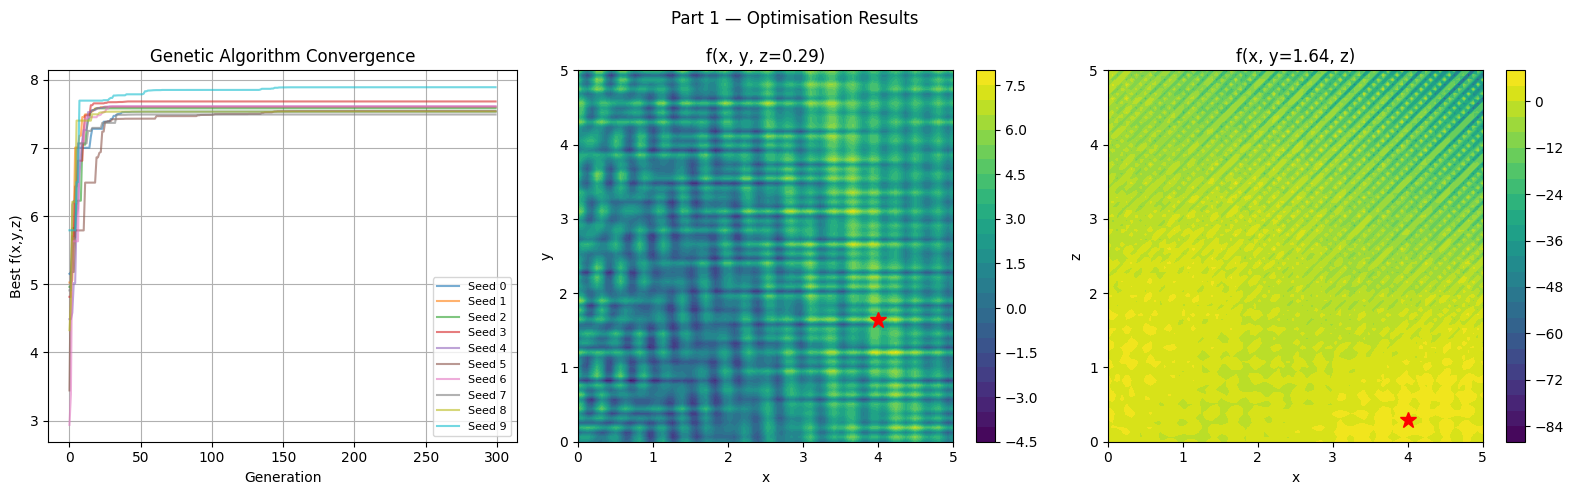

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(16, 5))


# Plot 1: Genetic Algorithm Convergence

ax1 = fig.add_subplot(1, 3, 1)

for i in range(len(ga_histories)):
    ax1.plot(ga_histories[i], label=f'Seed {i}', alpha=0.6)

ax1.set_xlabel('Generation')
ax1.set_ylabel('Best f(x,y,z)')
ax1.set_title('Genetic Algorithm Convergence')
ax1.legend(fontsize=8)
ax1.grid(True)


# Common grid setup
res = 80
xr = np.linspace(LOWER, UPPER, res)
yr = np.linspace(LOWER, UPPER, res)
zr = np.linspace(LOWER, UPPER, res)


# Plot 2: Contour x–y (z)
ax2 = fig.add_subplot(1, 3, 2)

X = []
Y = []
Z = []

for i in range(res):
    row_x = []
    row_y = []
    row_z = []

    for j in range(res):
        x = xr[j]
        y = yr[i]

        row_x.append(x)
        row_y.append(y)
        row_z.append(f(x, y, best_z))

    X.append(row_x)
    Y.append(row_y)
    Z.append(row_z)

cp2 = ax2.contourf(X, Y, Z, levels=25)
fig.colorbar(cp2, ax=ax2)

ax2.plot(best_x, best_y, 'r*', markersize=12)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title(f'f(x, y, z={best_z:.2f})')


# Plot 3: Contour x–z (y)
ax3 = fig.add_subplot(1, 3, 3)

X2 = []
Z2 = []
Y2 = []

for i in range(res):
    row_x = []
    row_z = []
    row_y = []

    for j in range(res):
        x = xr[j]
        z = zr[i]

        row_x.append(x)
        row_z.append(z)
        row_y.append(f(x, best_y, z))

    X2.append(row_x)
    Z2.append(row_z)
    Y2.append(row_y)

cp3 = ax3.contourf(X2, Z2, Y2, levels=25)
fig.colorbar(cp3, ax=ax3)

ax3.plot(best_x, best_z, 'r*', markersize=12)
ax3.set_xlabel('x')
ax3.set_ylabel('z')
ax3.set_title(f'f(x, y={best_y:.2f}, z)')


# Final layout
plt.suptitle('Part 1 — Optimisation Results')
plt.tight_layout()
plt.savefig('part1_results.png', dpi=150)
plt.show()

---
## Part 2: Distribution Network Optimisation

### Problem Statement

A distribution network has **2 warehouses** (W1, W2) and **23 stores**.  
We must determine:
1. **Which warehouse serves which stores** (store allocation).
2. **What routes vehicles take** from each warehouse to deliver to its stores (vehicle routing).

### Constraints

| Vehicle | Max stores per route | Cost per mile |
|---------|---------------------|---------------|
| Van     | 5                   | £2/mile       |
| Lorry   | 18                  | £3/mile       |

**Goal:** Minimise total daily delivery cost.


### Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Load coordinates
df = pd.read_excel('data.xlsx', sheet_name=0, header=None)

stores = np.array([[df.iloc[i, 1], df.iloc[i, 2]] for i in range(1, 24)], dtype=float)
w1 = np.array([df.iloc[24, 1], df.iloc[24, 2]], dtype=float)
w2 = np.array([df.iloc[25, 1], df.iloc[25, 2]], dtype=float)
warehouses = np.array([w1, w2])

#  Load distance matrix from the spreadsheet
# Rows 28-53, columns 2-27 (lower triangle + warehouse columns)
# We reconstruct the full symmetric matrix.

N = 23  # stores
labels = list(range(1, N+1)) + ['W1', 'W2']  # 25 labels

raw = df.iloc[28:54, 1:27].values  # shape (25, 25) approximately

# The spreadsheet provides a lower-triangle distance matrix (rows=29-53, cols=2-26)
# Index mapping: store i (1-indexed) is at matrix row/col i-1; W1=23, W2=24
dist_full = np.zeros((25, 25))

for r in range(25):      # 0..24  → stores 1-23, W1, W2
    for c in range(25):
        val = df.iloc[29 + r, 2 + c]
        if pd.notna(val) and val != '':
            try:
                v = float(val)
                dist_full[r, c] = v
                dist_full[c, r] = v   # symmetric
            except (ValueError, TypeError):
                pass

# Store-to-store: indices 0-22  (stores 1-23)
# W1: index 23,  W2: index 24
dist_matrix = dist_full[:23, :23]       # shape (23, 23)
dist_to_w1  = dist_full[:23, 23]        # length 23
dist_to_w2  = dist_full[:23, 24]        # length 23

print("Data loaded successfully.")
print(f"  Stores: {len(stores)}")
print(f"  W1 at ({w1[0]:.0f}, {w1[1]:.0f}),  W2 at ({w2[0]:.0f}, {w2[1]:.0f})")
print(f"  Distance matrix shape: {dist_matrix.shape}")
print(f"Sample distances from W1: {dict(zip(range(1,6), dist_to_w1[:5].round(1)))}")
print(f"Sample distances from W2: {dict(zip(range(1,6), dist_to_w2[:5].round(1)))}")


Data loaded successfully.
  Stores: 23
  W1 at (21, 25),  W2 at (37, 70)
  Distance matrix shape: (23, 23)
Sample distances from W1: {1: np.float64(16.6), 2: np.float64(96.2), 3: np.float64(57.1), 4: np.float64(90.4), 5: np.float64(87.7)}
Sample distances from W2: {1: np.float64(54.0), 2: np.float64(57.4), 3: np.float64(17.0), 4: np.float64(58.4), 5: np.float64(50.3)}


### Helper Functions

All distance calculations use the **Euclidean distances provided in the spreadsheet's distance matrix**, which are in miles. Vehicle costs are £2/mile (van) and £3/mile (lorry) as specified.


In [ ]:
# Vehicle parameters (from assignment)
VAN_CAPACITY   = 5    # max stores per van route
LORRY_CAPACITY = 18   # max stores per lorry route
VAN_COST       = 2    # £ per mile
LORRY_COST     = 3    # £ per mile

def route_distance(route, dist_to_wh, dm):
    """Total distance: warehouse → stores in route - warehouse."""
    if len(route) == 0:
        return 0.0
    d = dist_to_wh[route[0]]
    for i in range(len(route) - 1):
        d += dm[route[i], route[i+1]]
    d += dist_to_wh[route[-1]]
    return d

def route_cost(route, dist_to_wh, dm):
    """
    Cost of a route choosing the cheapest valid vehicle.
    Returns (cost, vehicle_type) or (inf, None) if route is infeasible.
    """
    n = len(route)
    if n == 0:
        return 0.0, None
    if n > LORRY_CAPACITY:
        return float('inf'), None   # infeasible

    dist = route_distance(route, dist_to_wh, dm)
    lorry = dist * LORRY_COST

    if n <= VAN_CAPACITY:
        van = dist * VAN_COST
        if van <= lorry:
            return van, 'van'

    return lorry, 'lorry'

print("Helper functions defined.")
print(f"  Van:   £{VAN_COST}/mile, max {VAN_CAPACITY} stores/route")
print(f"  Lorry: £{LORRY_COST}/mile, max {LORRY_CAPACITY} stores/route")


Helper functions defined.
  Van:   £2/mile, max 5 stores/route
  Lorry: £3/mile, max 18 stores/route


### Store Allocation to Warehouses

Each store is allocated to whichever warehouse is **closer** (using the provided distance matrix). This is a greedy baseline. The routing GA then operates independently for each warehouse's store group.

A trial of all-to-W1 and all-to-W2 is also made so the final cost reflects the best allocation found.


Nearest-warehouse allocation:
  W1 serves 9 stores: [1, 6, 8, 11, 12, 14, 17, 19, 20]
  W2 serves 14 stores: [2, 3, 4, 5, 7, 9, 10, 13, 15, 16, 18, 21, 22, 23]


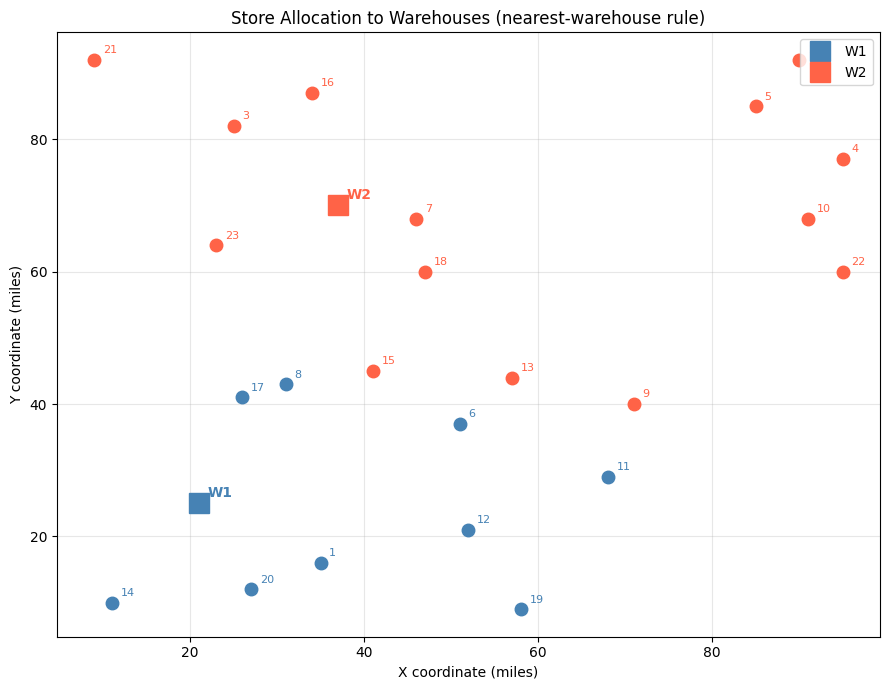

In [ ]:
# Nearest-warehouse allocation
stores_w1, stores_w2 = [], []
for i in range(23):
    if dist_to_w1[i] <= dist_to_w2[i]:
        stores_w1.append(i)
    else:
        stores_w2.append(i)

print("Nearest-warehouse allocation:")
print(f"  W1 serves {len(stores_w1)} stores: {[s+1 for s in sorted(stores_w1)]}")
print(f"  W2 serves {len(stores_w2)} stores: {[s+1 for s in sorted(stores_w2)]}")

# Map visualisation
fig, ax = plt.subplots(figsize=(9, 7))

for i in stores_w1:
    ax.plot(stores[i,0], stores[i,1], 'o', color='steelblue', markersize=9, zorder=3)
    ax.annotate(str(i+1), (stores[i,0]+1, stores[i,1]+1), fontsize=8, color='steelblue')

for i in stores_w2:
    ax.plot(stores[i,0], stores[i,1], 'o', color='tomato', markersize=9, zorder=3)
    ax.annotate(str(i+1), (stores[i,0]+1, stores[i,1]+1), fontsize=8, color='tomato')

ax.plot(*w1, 's', color='steelblue', markersize=14, zorder=4, label='W1')
ax.plot(*w2, 's', color='tomato',    markersize=14, zorder=4, label='W2')
ax.annotate('W1', w1 + np.array([1,1]), fontsize=10, fontweight='bold', color='steelblue')
ax.annotate('W2', w2 + np.array([1,1]), fontsize=10, fontweight='bold', color='tomato')

ax.set_xlabel('X coordinate (miles)'); ax.set_ylabel('Y coordinate (miles)')
ax.set_title('Store Allocation to Warehouses (nearest-warehouse rule)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('part2_allocation.png', dpi=150, bbox_inches='tight')
plt.show()


### Genetic Algorithm for Vehicle Routing (GA-VRP)


In [ ]:
def vrp_ga(store_indices, dist_to_wh, dm,
           pop_size=150, n_gen=500, p_mut=0.15, elite=5, seed=0):
    """
    Genetic Algorithm for the capacitated VRP.
    Returns (best_cost, best_routes, history).
    best_routes is a list of (route, vehicle_type, distance, cost).
    """
    rng = random.Random(seed)
    n = len(store_indices)

    if n == 0:
        return 0.0, [], []

    # Decode permutation into routes
    def decode(perm):
        routes, cur = [], []
        for s in perm:
            if len(cur) < LORRY_CAPACITY:
                cur.append(s)
            else:
                routes.append(cur)
                cur = [s]
        if cur:
            routes.append(cur)
        return routes

    # Fitness
    def evaluate(perm):
        routes = decode(perm)
        total = 0.0
        details = []
        for r in routes:
            c, vtype = route_cost(r, dist_to_wh, dm)
            dist = route_distance(r, dist_to_wh, dm)
            total += c
            details.append((r, vtype, dist, c))
        return -total, total, details

    # Ordered crossover (OX)
    def ox(p1, p2):
        s, e = sorted(rng.sample(range(n), 2))
        child = [None] * n
        child[s:e+1] = p1[s:e+1]
        fill = [g for g in p2 if g not in child]
        fi = 0
        for i in range(n):
            if child[i] is None:
                child[i] = fill[fi]; fi += 1
        return child

    # Swap mutation
    def mutate(perm):
        perm = perm[:]
        if n > 1 and rng.random() < p_mut:
            i, j = rng.sample(range(n), 2)
            perm[i], perm[j] = perm[j], perm[i]
        return perm

    # Initialise
    si = list(store_indices)
    pop = [rng.sample(si, n) for _ in range(pop_size)]
    best_cost = float('inf')
    best_routes = []
    history = []

    for gen in range(n_gen):
        evaluated = [evaluate(ind) for ind in pop]
        fits  = [e[0] for e in evaluated]
        costs = [e[1] for e in evaluated]
        dets  = [e[2] for e in evaluated]

        best_idx = int(np.argmin(costs))
        if costs[best_idx] < best_cost:
            best_cost   = costs[best_idx]
            best_routes = dets[best_idx]
        history.append(best_cost)

        # Elitism
        sorted_idx = sorted(range(pop_size), key=lambda i: costs[i])
        new_pop = [pop[i][:] for i in sorted_idx[:elite]]

        # Tournament selection + crossover + mutation
        while len(new_pop) < pop_size:
            t1 = min(rng.sample(range(pop_size), 3), key=lambda i: costs[i])
            t2 = min(rng.sample(range(pop_size), 3), key=lambda i: costs[i])
            child = ox(pop[t1], pop[t2])
            child = mutate(child)
            new_pop.append(child)

        pop = new_pop

    return best_cost, best_routes, history


print("Genetic Algorithm-VRP function defined.")


Genetic Algorithm-VRP function defined.


### Solve VRP for Each Warehouse

In [ ]:
print("Solving VRP for Warehouse 1...")
cost_w1, routes_w1, hist_w1 = vrp_ga(stores_w1, dist_to_w1, dist_matrix, seed=42)
print(f"  W1 total cost: £{cost_w1:.2f}")

print("\nSolving VRP for Warehouse 2...")
cost_w2, routes_w2, hist_w2 = vrp_ga(stores_w2, dist_to_w2, dist_matrix, seed=42)
print(f"  W2 total cost: £{cost_w2:.2f}")

total_cost = cost_w1 + cost_w2
print()
print(f"TOTAL DAILY COST: £{total_cost:.2f}")
print()


Solving VRP for Warehouse 1...
  W1 total cost: £475.20

Solving VRP for Warehouse 2...
  W2 total cost: £883.50

TOTAL DAILY COST: £1358.70



### Route Summary

In [ ]:
def print_routes(routes, wh_label):
    vans = lorries = 0
    for i, (route, vtype, dist, cost) in enumerate(routes):
        store_nums = [s+1 for s in route]
        print(f"  {wh_label} Route {i+1}: {vtype.upper():5s} | Stores {store_nums} | {dist:.1f} miles | £{cost:.2f}")
        if vtype == 'van': vans += 1
        else: lorries += 1
    print(f"  - {vans} van(s), {lorries} lorr(ies)  |  subtotal £{sum(c for _,_,_,c in routes):.2f}")
    return vans, lorries

print("WAREHOUSE 1 ROUTES")
v1, l1 = print_routes(routes_w1, 'W1')
print()

print("WAREHOUSE 2 ROUTES")
v2, l2 = print_routes(routes_w2, 'W2')

print()
print(f"TOTAL VEHICLES: {v1+v2} van(s), {l1+l2} lorr(ies)")
print(f"TOTAL DAILY COST: £{total_cost:.2f}")
print()


WAREHOUSE 1 ROUTES
  W1 Route 1: LORRY | Stores [17, 8, 6, 11, 19, 12, 1, 20, 14] | 158.4 miles | £475.20
  - 0 van(s), 1 lorr(ies)  |  subtotal £475.20

WAREHOUSE 2 ROUTES
  W2 Route 1: LORRY | Stores [7, 18, 13, 5, 2, 4, 10, 22, 9, 15, 23, 21, 3, 16] | 294.5 miles | £883.50
  - 0 van(s), 1 lorr(ies)  |  subtotal £883.50

TOTAL VEHICLES: 0 van(s), 2 lorr(ies)
TOTAL DAILY COST: £1358.70



### Route Visualisation

/tmp/ipykernel_4708/1980435200.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  ax.plot(*wh_coord, 'bo', color='black', markersize=18, zorder=5, label=wh_label)


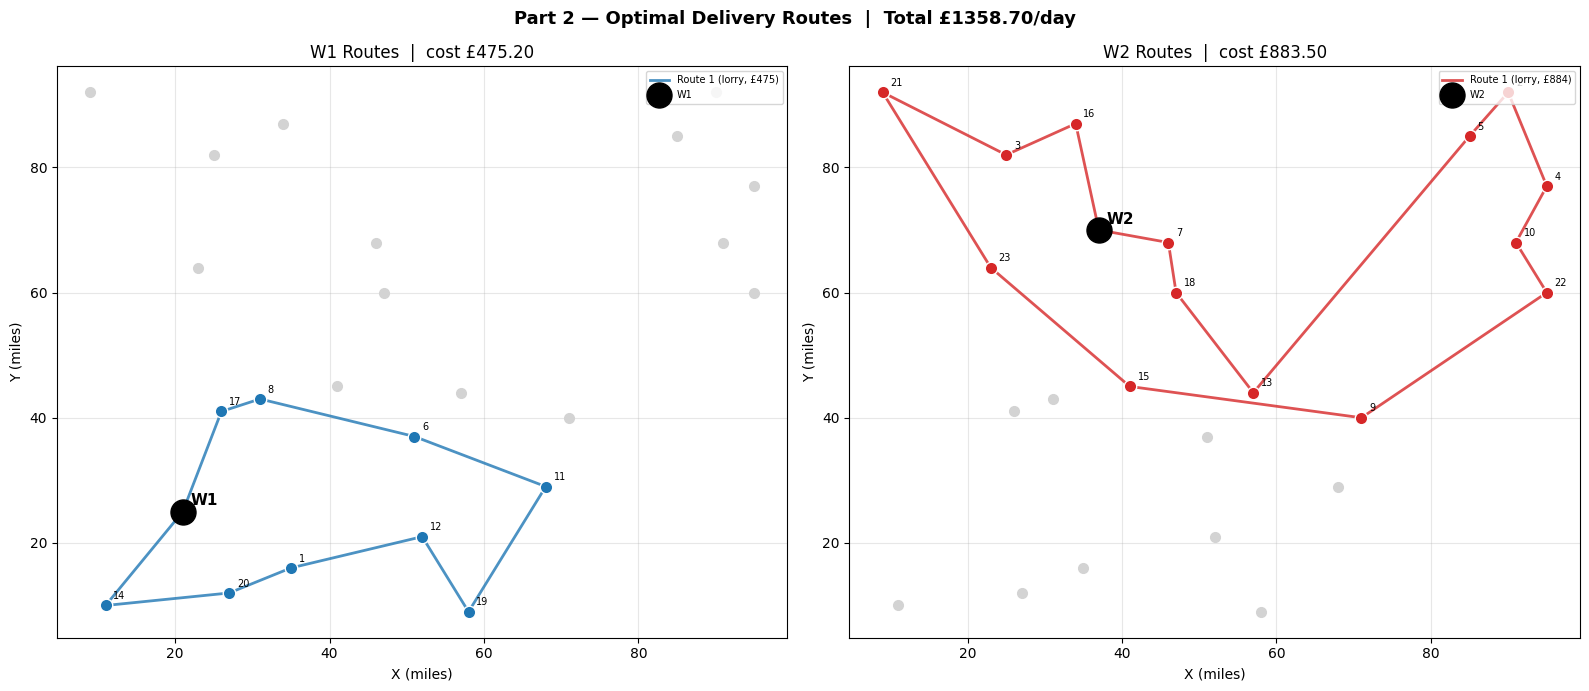

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

palette_w1 = ['#1f77b4','#aec7e8','#17becf','#9edae5','#006ba4']
palette_w2 = ['#d62728','#ff9896','#e377c2','#f7b6d2','#a02020']

for ax, wh_coord, wh_routes, wh_stores, pal, wh_label, opp_stores in [
    (axes[0], w1, routes_w1, stores_w1, palette_w1, 'W1', stores_w2),
    (axes[1], w2, routes_w2, stores_w2, palette_w2, 'W2', stores_w1),
]:
    # Background stores (other warehouse)
    for i in opp_stores:
        ax.plot(stores[i,0], stores[i,1], 'o', color='lightgray', markersize=7, zorder=2)

    # Route lines
    for ri, (route, vtype, dist, cost) in enumerate(wh_routes):
        color = pal[ri % len(pal)]
        coords = [wh_coord] + [stores[s] for s in route] + [wh_coord]
        coords = np.array(coords)
        ax.plot(coords[:,0], coords[:,1], '-', color=color, linewidth=2, alpha=0.8,
                label=f'Route {ri+1} ({vtype}, £{cost:.0f})')
        for s in route:
            ax.plot(stores[s,0], stores[s,1], 'o', color=color, markersize=9,
                    markeredgecolor='white', markeredgewidth=1, zorder=4)
            ax.annotate(str(s+1), (stores[s,0]+1, stores[s,1]+1), fontsize=7, color='black')

    # Warehouse marker
    ax.plot(*wh_coord, 'bo', color='black', markersize=18, zorder=5, label=wh_label)
    ax.annotate(wh_label, wh_coord + np.array([1,1]), fontsize=11, fontweight='bold')

    ax.set_xlabel('X (miles)'); ax.set_ylabel('Y (miles)')
    ax.set_title(f'{wh_label} Routes  |  cost £{sum(c for _,_,_,c in wh_routes):.2f}')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Part 2 — Optimal Delivery Routes  |  Total £{total_cost:.2f}/day',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('part2_routes.png', dpi=150, bbox_inches='tight')
plt.show()


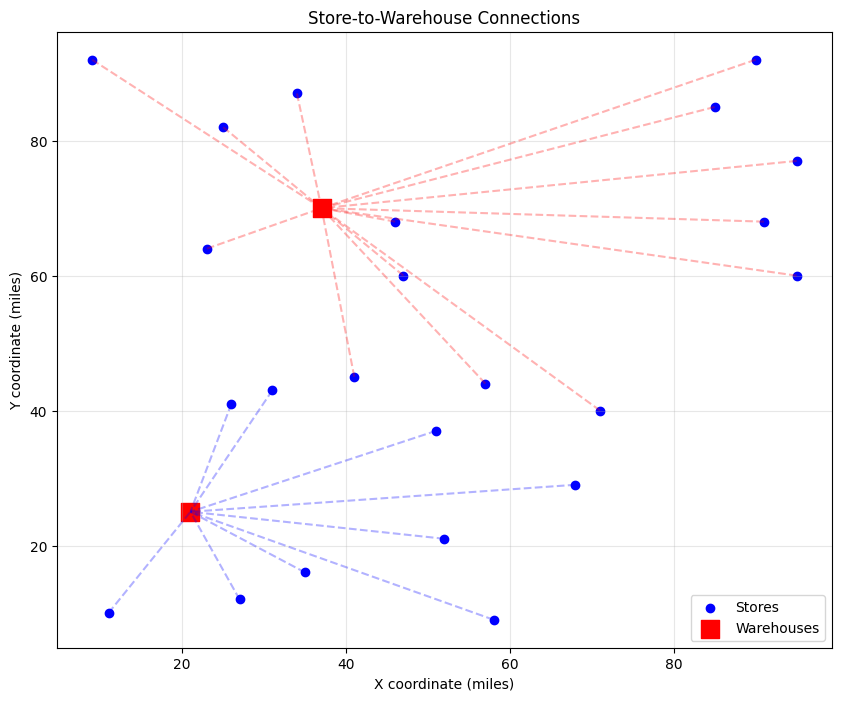

In [ ]:
plt.figure(figsize=(10, 8))

# Plot stores
plt.scatter(stores[:, 0], stores[:, 1], c='blue', label='Stores')

# Plot warehouses
plt.scatter(warehouses[:, 0], warehouses[:, 1],
            c='red', marker='s', s=150, label='Warehouses')

# Draw lines to nearest warehouse
for i, store in enumerate(stores):
    if dist_to_w1[i] < dist_to_w2[i]:
        plt.plot([store[0], warehouses[0][0]],
                 [store[1], warehouses[0][1]], 'b--', alpha=0.3)
    else:
        plt.plot([store[0], warehouses[1][0]],
                 [store[1], warehouses[1][1]], 'r--', alpha=0.3)

plt.xlabel('X coordinate (miles)')
plt.ylabel('Y coordinate (miles)')
plt.title('Store-to-Warehouse Connections')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('part3_store_connections.png', dpi=300)
plt.show()

### Genetic Algorithm Convergence

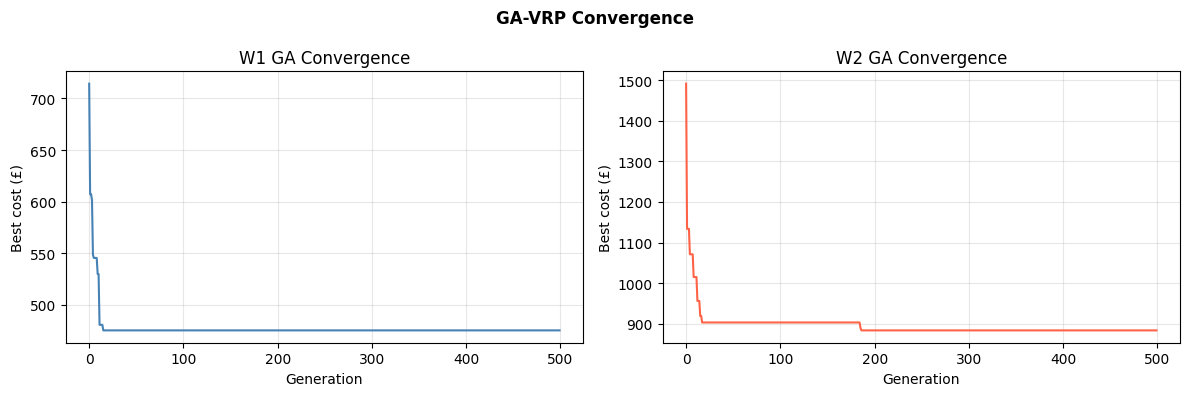

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_w1, color='steelblue', linewidth=1.5)
ax1.set_xlabel('Generation'); ax1.set_ylabel('Best cost (£)')
ax1.set_title('W1 GA Convergence')
ax1.grid(True, alpha=0.3)

ax2.plot(hist_w2, color='tomato', linewidth=1.5)
ax2.set_xlabel('Generation'); ax2.set_ylabel('Best cost (£)')
ax2.set_title('W2 GA Convergence')
ax2.grid(True, alpha=0.3)

plt.suptitle('GA-VRP Convergence', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('part2_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
